# Домашняя работа: NLP Transformer с нуля на PyTorch

В этой домашней работе вы реализуете основные компоненты Transformer для обработки текста:

- character-level токенизацию;
- token embeddings;
- positional embeddings;
- scaled dot-product attention;
- multi-head self-attention;
- causal mask;
- Transformer block;
- decoder-only MiniGPT;
- генерацию текста.

In [1]:
import math
import random
from dataclasses import dataclass
from IPython.display import display, HTML
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", DEVICE)

torch.manual_seed(42)
random.seed(42)


DEVICE: cpu


## 1. Данные

Ниже есть предзаполненный text, на котором можно обучать трансформер, однако, будет гораздо интереснее, если используете свой текст
Модель будет учиться предсказывать следующий символ.

In [2]:
# Я использовал отрывок из книги "Алхимик", которую написал Пауэло Коэльо

text = """
The boy's name was Santiago. 
Dusk was falling as the boy arrived with his herd at an abandoned church. 
The roof had fallen in long ago, and an enormous sycamore had grown on the spot where the sacristy had once stood.
He decided to spend the night there. 
He saw to it that all the sheep entered through the ruined gate, and then laid some planks across it to prevent the flock from wandering away during the night. 
There were no wolves in the region, but once an animal had strayed during the night, and the boy had had to spend the entire next day searching for it.
He swept the floor with his jacket and lay down, using the book he had just finished reading as a pillow. 
He told himself that he would have to start reading thicker books: they lasted longer, and made more comfortable pillows.
It was still dark when he awoke, and, looking up, he could see the stars through the half-destroyed roof.
I wanted to sleep a little longer, he thought. He had had the same dream that night as a week ago, and once again he had awakened before it ended.
He arose and, taking up his crook, began to awaken the sheep that still slept. He had noticed that, as soon as he awoke, most of his animals also began to stir. 
It was as if some mysterious energy bound his life to that of the sheep, with whom he had spent the past two years, leading them through the countryside in search of food and water. 
"They are so used to me that they know my schedule," he muttered. 
Thinking about that for a moment, he realized that it could be the other way around: that it was he who had become accustomed to their schedule.
But there were certain of them who took a bit longer to awaken. 
The boy prodded them, one by one, with his crook, calling each by name. 
He had always believed that the sheep were able to understand what he said. 
So there were times when he read them parts of his books that had made an impression on him, or when he would tell them of the loneliness or the happiness of a shepherd in the fields. 
Sometimes he would comment to them on the things he had seen in the villages they passed.

But for the past few days he had spoken to them about only one thing: the girl, the daughter of a merchant who lived in the village they would reach in about four days. 
He had been to the village only once, the year before. 
The merchant was the proprietor of a dry goods shop, and he always demanded that the sheep be sheared in his presence, so that he would not be cheated. 
A friend had told the boy about the shop, and he had taken his sheep there.
"I need to sell some wool," the boy told the merchant.
The shop was busy, and the man asked the shepherd to wait until the afternoon. 
So the boy sat on the steps of the shop and took a book from his bag.
"I didn't know shepherds knew how to read," said a girl's voice behind him.
The girl was typical of the region of Andalusia, with flowing black hair, and eyes that vaguely recalled the Moorish conquerors.
"Well, usually I learn more from my sheep than from books," he answered. 
During the two hours that they talked, she told him she was the merchant's daughter, and spoke of life in the village, where each day was like all the others. 
The shepherd told her of the Andalusian countryside, and related the news from the other towns where he had stopped. It was a pleasant change from talking to his sheep.
"How did you learn to read?" the girl asked at one point.
"Like everybody learns," he said. "In school."
"Well, if you know how to read, why are you just a shepherd?"
The boy mumbled an answer that allowed him to avoid responding to her question. 
He was sure the girl would never understand. 
He went on telling stories about his travels, and her bright, Moorish eyes went wide with fear and surprise. 
As the time passed, the boy found himself wishing that the day would never end, that her father would stay busy and keep him waiting for three days. 
He recognized that he was feeling something he had never experienced before: the desire to live in one place forever. 
With the girl with the raven hair, his days would never be the same again.
But finally the merchant appeared, and asked the boy to shear four sheep. 
He paid for the wool and asked the shepherd to come back the following year.

And now it was only four days before he would be back in that same village. 
He was excited, and at the same time uneasy: maybe the girl had already forgotten him. 
Lots of shepherds passed through, selling their wool.
"It doesn't matter," he said to his sheep. "I know other girls in other places."
But in his heart he knew that it did matter. 
And he knew that shepherds, like seamen and like traveling salesmen, always found a town where there was someone who could make them forget the joys of carefree wandering.
The day was dawning, and the shepherd urged his sheep in the direction of the sun. 
They never have to make any decisions, he thought. 
Maybe that's why they always stay close to me.
The only things that concerned the sheep were food and water. 
As long as the boy knew how to find the best pastures in Andalusia, they would be his friends. 
Yes, their days were all the same, with the seemingly endless hours between sunrise and dusk; and they had never read a book in their young lives, and didn't understand when the boy told them about the sights of the cities. 
They were content with just food and water, and, in exchange, they generously gave of their wool, their company, and—once in a while—their meat.
If I became a monster today, and decided to kill them, one by one, they would become aware only after most of the flock had been slaughtered, thought the boy. 
They trust me, and they've forgotten how to rely on their own instincts, because I lead them to nourishment.
The boy was surprised at his thoughts. 
Maybe the church, with the sycamore growing from within, had been haunted. 
It had caused him to have the same dream for a second time, and it was causing him to feel anger toward his faithful companions. 
He drank a bit from the wine that remained from his dinner of the night before, and he gathered his jacket closer to his body. 
He knew that a few hours from now, with the sun at its zenith, the heat would be so great that he would not be able to lead his flock across the fields. 
It was the time of day when all of Spain slept during the summer. 
The heat lasted until nightfall, and all that time he had to carry his jacket. 
But when he thought to complain about the burden of its weight, he remembered that, because he had the jacket, he had withstood the cold of the dawn.
We have to be prepared for change, he thought, and he was grateful for the jacket's weight and warmth.
The jacket had a purpose, and so did the boy. 
His purpose in life was to travel, and, after two years of walking the Andalusian terrain, he knew all the cities of the region. 
He was planning, on this visit, to explain to the girl how it was that a simple shepherd knew how to read. That he had attended a seminary until he was sixteen. 
His parents had wanted him to become a priest, and thereby a source of pride for a simple farm family. They worked hard just to have food and water, like the sheep. 
He had studied Latin, Spanish, and theology. But ever since he had been a child, he had wanted to know the world, and this was much more important to him than knowing God and learning about man's sins. 
One afternoon, on a visit to his family, he had summoned up the courage to tell his father that he didn't want to become a priest. 
That he wanted to travel.

"People from all over the world have passed through this village, son," said his father. 
"They come in search of new things, but when they leave they are basically the same people they were when they arrived. 
They climb the mountain to see the castle, and they wind up thinking that the past was better than what we have now.
They have blond hair, or dark skin, but basically they're the same as the people who live right here."
"But I'd like to see the castles in the towns where they live," the boy explained.
"Those people, when they see our land, say that they would like to live here forever," his father continued.
"Well, I'd like to see their land, and see how they live," said his son.
"The people who come here have a lot of money to spend, so they can afford to travel," his father said. 
"Amongst us, the only ones who travel are the shepherds."
"Well, then I'll be a shepherd!"
His father said no more.
The next day, he gave his son a pouch that held three ancient Spanish gold coins.
"I found these one day in the fields.
I wanted them to be a part of your inheritance. 
But use them to buy your flock. Take to the fields, and someday you'll learn that our countryside is the best, and our women the most beautiful."
And he gave the boy his blessing. 
The boy could see in his father's gaze a desire to be able, himself, to travel the world—a desire that was still alive, despite his father's having had to bury it, over dozens of years, under the burden of struggling for water to drink, food to eat, and the same place to sleep every night of his life.

The horizon was tinged with red, and suddenly the sun appeared. 
The boy thought back to that conversation with his father, and felt happy; he had already seen many castles and met many women (but none the equal of the one who awaited him several days hence). 
He owned a jacket, a book that he could trade for another, and a flock of sheep. 
But, most important, he was able every day to live out his dream. 
If he were to tire of the Andalusian fields, he could sell his sheep and go to sea. 
By the time he had had enough of the sea, he would already have known other cities, other women, and other chances to be happy. 
I couldn't have found God in the seminary, he thought, as he looked at the sunrise.
Whenever he could, he sought out a new road to travel. 
He had never been to that ruined church before, in spite of having traveled through those parts many times. 
The world was huge and inexhaustible; he had only to allow his sheep to set the route for a while, and he would discover other interesting things. 
The problem is that they don't even realize that they're walking a new road every day. 
They don't see that the fields are new and the seasons change. 
All they think about is food and water.
Maybe we're all that way, the boy mused. 
Even me—I haven't thought of other women since I met the merchant's daughter. 
Looking at the sun, he calculated that he would reach Tarifa before midday. 
There, he could exchange his book for a thicker one, fill his wine bottle, shave, and have a haircut; he had to prepare himself for his meeting with the girl, and he didn't want to think about the possibility that some other shepherd, with a larger flock of sheep, had arrived there before him and asked for her hand.
It's the possibility of having a dream come true that makes life interesting, he thought, as he looked again at the position of the sun, and hurried his pace. 
He had suddenly remembered that, in Tarifa, there was an old woman who interpreted dreams.


this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
"""

text = text.lower()
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print("Text length:", len(text))
print("Vocab size:", vocab_size)
print("Vocabulary:", "".join(chars))

Text length: 11398
Vocab size: 40
Vocabulary: 
 !"'(),-.:;?abcdefghijklmnopqrstuvwxyz—


## 2. Кодирование и декодирование текста

### Задание 1

Реализуйте функции:

- `encode(s)` — переводит строку в список индексов;
- `decode(ids)` — переводит список индексов обратно в строку.

In [3]:
def encode(s: str) -> list[int]:
    # TODO: верните список индексов символов через stoi
    stoi_list = [stoi[ch] for ch in s]
    return stoi_list
    


def decode(ids: list[int]) -> str:
    # TODO: верните строку по списку индексов через itos
    itos_list = ''.join(itos[id] for id in ids)
    return itos_list

In [4]:
sample = "attention"
ids = encode(sample)
assert isinstance(ids, list)
assert all(isinstance(i, int) for i in ids)
assert decode(ids) == sample
print("Encoding/decoding tests passed")

Encoding/decoding tests passed


## 3. Train/validation split

In [5]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

Train tokens: 10258
Val tokens: 1140


## 4. Создание batch

Для каждого входного токена - нам нужно предсказать следующий токен нашей последовательности.

```text
x = [t, r, a, n]
y = [r, a, n, s]
```


### Реализуйте функцию `get_batch`.

In [6]:
block_size = 32
batch_size = 16

def get_batch(split: str):
    source = train_data if split == "train" else val_data
    ############################################################################
    # TODO:
    # 1. Случайно выберите batch_size стартовых позиций.
    # 2. Для каждой позиции возьмите block_size токенов в x.
    # 3. Для y возьмите те же токены, но сдвинутые на 1 вправо.
    # 4. Перенесите x и y на DEVICE.
    ############################################################################
    ix = torch.randint(0, len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix]) 
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x, y
    
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
    
    

In [7]:
x, y = get_batch("train")
assert x.shape == (batch_size, block_size)
assert y.shape == (batch_size, block_size)
assert x.device.type == torch.device(DEVICE).type
assert y.device.type == torch.device(DEVICE).type
print("Batch tests passed")

Batch tests passed


## 5. Scaled Dot-Product Attention

Attention вычисляет, насколько каждый токен должен смотреть на другие токены.

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

###  Реализуйте функцию `scaled_dot_product_attention`.

In [8]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    q, k, v: [B, H, T, D]
    mask: [T, T] или None
    """
    ############################################################################
    # TODO:
    # 1. scores = q @ k^T / sqrt(D)
    # 2. если mask не None, запретите смотреть в masked-позиции
    # 3. softmax по последней размерности
    # 4. умножьте attention weights на v
    ############################################################################
    
    D = q.shape[-1]
    scores = q @ k.transpose(-2, -1) / (D ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    attn = torch.softmax(scores, dim=-1)
    out = attn @ v

    return out, attn
    
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [9]:
B, H, T, D = 2, 4, 8, 16
q = torch.randn(B, H, T, D)
k = torch.randn(B, H, T, D)
v = torch.randn(B, H, T, D)

out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (B, H, T, D)
assert attn.shape == (B, H, T, T)
assert torch.allclose(attn.sum(dim=-1), torch.ones(B, H, T), atol=1e-5)
print("Scaled attention tests passed")

Scaled attention tests passed


## 6. Causal mask

В NLP модель должна предсказывать следующий токен, опираясь только на уже известные предыдущие токены. Если разрешить ей на будущие позиции, она будет использовать информацию из ответа, что делает обучение некорректным и нереалистичным. Поэтому мы вводим causal mask — матрицу, которая для каждой позиции разрешает учитывать только текущие и предыдущие токены, но запрещает доступ к будущим.


### Реализуйте `make_causal_mask`.

In [10]:
def make_causal_mask(seq_len: int, device=None):
    # TODO: верните bool-матрицу [seq_len, seq_len], где True = можно смотреть
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool))
    return mask

In [11]:
mask = make_causal_mask(4)
expected = torch.tensor([
    [1, 0, 0, 0],
    [1, 1, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 1],
], dtype=torch.bool)
assert mask.shape == (4, 4)
assert torch.equal(mask.cpu(), expected)
print("Causal mask tests passed")

Causal mask tests passed


## 7. Multi-Head Self-Attention

Реализуйте класс `MultiHeadSelfAttention`.

Класс `MultiHeadSelfAttention` сначала проецирует входные эмбеддинги в три матрицы — запросы (Q), ключи (K) и значения (V) — с помощью линейного слоя, после чего разбивает их на несколько “голов”. Для каждой головы независимо считается scaled dot-product attention, затем результаты объединяются обратно в единое представление и проходят через финальную линейную проекцию, позволяя модели одновременно учитывать разные типы зависимостей между токенами.

In [12]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.last_attention = None

    def forward(self, x, mask=None):
        B, T, C = x.shape
        ############################################################################
        # TODO:
        # 1. получите qkv
        # 2. разделите q, k, v
        # 3. приведите к форме [B, H, T, D]
        # 4. вызовите scaled_dot_product_attention
        # 5. объедините головы обратно в [B, T, C]
        # 6. примените proj и dropout
        # 7. сохраните attention в self.last_attention
        ############################################################################
        
        qkv = self.qkv(x)
        q, k, v = torch.chunk(qkv, 3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        out, attn = scaled_dot_product_attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        out = self.proj(out)
        out = self.dropout(out)

        self.last_attention = attn
        
        return out

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

In [13]:
mha = MultiHeadSelfAttention(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
out = mha(x_demo, mask_demo)
assert out.shape == (2, 10, 64)
assert mha.last_attention is not None
assert mha.last_attention.shape == (2, 4, 10, 10)
print("Multi-head attention tests passed")

Multi-head attention tests passed


## 8. Feed Forward Network

### Реализуйте `FeedForward`.

In [14]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        ############################################################################
        # TODO: nn.Sequential: Linear -> GELU -> Linear -> Dropout
        ############################################################################

        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

    def forward(self, x):
        return self.net(x)

In [15]:
ff = FeedForward(embed_dim=64, hidden_dim=256)
x_demo = torch.randn(2, 10, 64)
out = ff(x_demo)
assert out.shape == (2, 10, 64)
print("FeedForward tests passed")

FeedForward tests passed


## 9. Transformer Block

Используем Pre-LN вариант:

```python
x = x + attention(layer_norm(x))
x = x + mlp(layer_norm(x))
```

### Реализуйте `TransformerBlock`.


In [16]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: int = 4, dropout: float = 0.1):
        super().__init__()
        ############################################################################
        # TODO: ln1, attn, ln2, ff
        ############################################################################

        hidden_dim = int(embed_dim * mlp_ratio)
        
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim, hidden_dim, dropout)

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask=mask)
        x = x + self.ff(self.ln2(x))
        return x

In [17]:
block = TransformerBlock(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
out = block(x_demo, mask_demo)
assert out.shape == (2, 10, 64)
print("TransformerBlock tests passed")

TransformerBlock tests passed


## 10. Конфигурация модели

In [18]:
@dataclass
class TransformerConfig:
    vocab_size: int
    block_size: int = 16
    embed_dim: int = 64
    num_heads: int = 4
    depth: int = 2
    dropout: float = 0.

## 11. MiniGPT / Decoder-only Transformer

### Реализуйте класс `MiniGPT`.

In [19]:
class MiniGPT(nn.Module):
    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.config = config
        self.token_embedding = nn.Embedding(config.vocab_size, config.embed_dim)
        self.position_embedding = nn.Embedding(config.block_size, config.embed_dim)
        self.dropout = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=config.embed_dim,
                num_heads=config.num_heads,
                mlp_ratio=4,
                dropout=config.dropout,
            )
            for _ in range(config.depth)
        ])

        self.ln_f = nn.LayerNorm(config.embed_dim)
        self.lm_head = nn.Linear(config.embed_dim, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.block_size
        ############################################################################
        # TODO:
        # 1. token embeddings
        # 2. positional embeddings
        # 3. сложить embeddings
        # 4. causal mask
        # 5. Transformer blocks
        # 6. logits
        # 7. loss, если targets is not None
        ############################################################################

        tok_emb = self.token_embedding(idx)
        pos = torch.arange(0, T, device=idx.device)
        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb
        x = self.dropout(x)

        mask = make_causal_mask(T, device=idx.device)

        for block in self.blocks:
            x = block(x, mask=mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            logits_flat = logits.view(B*T, -1)
            targets_flat = targets.view(B*T)
            loss = F.cross_entropy(logits_flat, targets_flat)
        
        return logits, loss

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0):
        """
        idx: [B, T]
        """
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx

In [20]:
config = TransformerConfig(vocab_size=vocab_size, 
                           block_size=32, 
                           embed_dim=128, 
                           num_heads=8, 
                           depth=6, 
                           dropout=0.2)
model = MiniGPT(config).to(DEVICE)
x, y = get_batch("train")
logits, loss = model(x, y)

print(f"{logits.shape}")
print(f"{batch_size}")
print(f"{block_size}")
print(f"{vocab_size}")

assert logits.shape == (batch_size, block_size, vocab_size)
assert loss is not None and loss.ndim == 0
start = torch.zeros((1, 1), dtype=torch.long, device=DEVICE)
generated = model.generate(start, max_new_tokens=10)
assert generated.shape == (1, 11)
print("MiniGPT tests passed")
print("Parameters:", sum(p.numel() for p in model.parameters()))

torch.Size([16, 32, 40])
16
32
40
MiniGPT tests passed
Parameters: 1204264


## 12. Оценка loss

### Реализуйте `estimate_loss`.

In [21]:
@torch.no_grad()
def estimate_loss(model, eval_iters: int = 20):
    model.eval()
    results = {}
    ############################################################################
    # TODO: посчитайте средний loss для train и val
    ############################################################################

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()
        results[split] = losses.mean().item()
    
    model.train()
    return results

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [22]:
losses = estimate_loss(model, eval_iters=2)
assert "train" in losses and "val" in losses
assert isinstance(losses["train"], float)
assert isinstance(losses["val"], float)
print("Estimate loss tests passed:", losses)

Estimate loss tests passed: {'train': 3.845515489578247, 'val': 3.8502533435821533}


## 13. Training loop

Поставьте `RUN_TRAINING=True`, когда все TODO реализованы.

In [23]:
config = TransformerConfig(vocab_size=vocab_size, 
                           block_size=32, 
                           embed_dim=64, 
                           num_heads=4, 
                           depth=2, 
                           dropout=0.1)

model = MiniGPT(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

max_iters = 1200
eval_interval = 100
loss_history = []

for step in range(max_iters):
    if step % eval_interval == 0:
        losses = estimate_loss(model, eval_iters=20)
        print(f"step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
print("Training finished")


step 0: train loss 3.8321, val loss 3.8581
step 100: train loss 2.6826, val loss 2.7221
step 200: train loss 2.4752, val loss 2.4732
step 300: train loss 2.3451, val loss 2.4011
step 400: train loss 2.3384, val loss 2.3446
step 500: train loss 2.2659, val loss 2.3093
step 600: train loss 2.2169, val loss 2.3013
step 700: train loss 2.1949, val loss 2.2603
step 800: train loss 2.1614, val loss 2.2538
step 900: train loss 2.1390, val loss 2.2465
step 1000: train loss 2.1208, val loss 2.2032
step 1100: train loss 2.1049, val loss 2.2045
Training finished


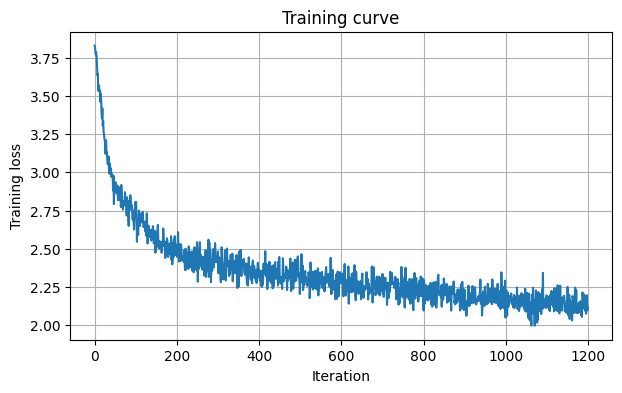

In [24]:
if loss_history:
    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Training loss")
    plt.title("Training curve")
    plt.grid(True)
    plt.show()

## 14. Генерация текста

In [25]:

model.eval()
prompt = "in andalysia"
idx = torch.tensor([encode(prompt)], dtype=torch.long, device=DEVICE)
out = model.generate(idx, max_new_tokens=300, temperature=0.8)
print(decode(out[0].tolist()))


in andalysiais busere, dan watngenme dangot ulrended ur the dancthec't wiched thrand oulingist ughe hit tim thead ther han the the an sas to the thed wird thendaurd the rais fot chereey mo he ouconcthed wa tolllld macke an holourde to has thep son whoughe gay the dorppone the counid he hoy af to to pllit taky t


## 15. Визуализация attention

In [26]:
def visualize_attention(model: MiniGPT, input_text: str, layer_id: int = -1, head_id: int = 0):
    model.eval()

    idx = torch.tensor([encode(input_text)], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        _ = model(idx)

    block = model.blocks[layer_id]
    attn = block.attn.last_attention

    assert attn is not None
    assert 0 <= head_id < attn.shape[1]

    attn_map = attn[0, head_id].detach().cpu()  # [T, T]
    tokens = list(input_text)

    plt.figure(figsize=(7, 6))
    plt.imshow(attn_map, cmap="viridis")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(f"Attention heatmap: layer={layer_id}, head={head_id}")

    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)

    plt.xlabel("Key / previous tokens")
    plt.ylabel("Query / current token")
    plt.tight_layout()
    plt.show()

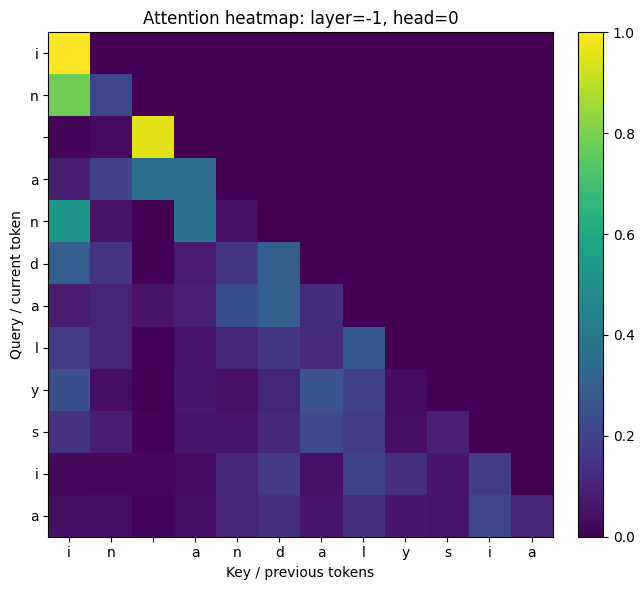

In [27]:

visualize_attention(model, "in andalysia", layer_id=-1, head_id=0)

## 16. Теоретическая часть

1. Почему attention делят на `sqrt(d_k)`?
2. Чем decoder-only Transformer отличается от encoder-only Transformer?
3. Что будет, если убрать residual connections?
4. Почему маленькая модель на маленьком тексте быстро переобучается?

1) При больших d_k скалярное произведение (q, k) может стать очень большим, а softmax от этого выдаст вектор с около нулевыми значениями кроме одного, а следствием этого будут очень маленькие градиенты.
2) decoder-only Transformer генерирует текст (последовательность токенов) по входящему последовательно сслева направо тексту. А encoder-only Transformer выдает один вектор для каждого токена по входящему целому тексту.
3) Без residual connections произойдет затухание градиентов
4) В небольшом тексте недостаточно примеров для выявления моделью достаточнго числа зкономерностей, поэтому маленькая модель просто запоминает полученный текст.



## Оценка модели

Perplexity — информативная метрика для языковых моделей, которая отражает уверенность модели в предсказаниях следующего токена. В отличие от accuracy, которая учитывает только точные совпадения, perplexity использует вероятности и "наказывает" модель даже за “почти правильные” ответы, если она не уверена. Кроме того, perplexity имеет понятную интерпретацию: это среднее “количество вариантов”, из которых модель как бы выбирает следующий токен — чем меньше, тем лучше модель понимает текст.

Значения perplexity можно оценить так:
- PPL примерно 1–2 - отлично (почти запомнила)
- PPL примерно 10–50 - нормально
- PPL > 100 - плохо

In [28]:
def perplexity(loss):
    """Perplexity = exp(loss)"""
    return torch.exp(torch.tensor(loss)).item()

@torch.no_grad()
def evaluate_loss_on_text_sampled(model, text, num_batches=50, batch_size=64):
    model.eval()

    data = torch.tensor(encode(text), dtype=torch.long).to(DEVICE)

    max_start = len(data) - block_size - 1
    if max_start <= 0:
        raise ValueError(
            f"Text is too short: len={len(data)}, block_size={block_size}"
        )

    losses = []

    for _ in range(num_batches):
        ix = torch.randint(0, max_start, (batch_size,), device=DEVICE)

        x = torch.stack([data[i:i + block_size] for i in ix])
        y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])

        _, loss = model(x, y)
        losses.append(loss.item())

    return sum(losses) / len(losses)

loss = evaluate_loss_on_text_sampled(model, text)
ppl = perplexity(loss)

In [29]:

display(HTML(f"<h1>Оценка Вашей модели: {ppl:.2f}</h1>"))